# Prediction de defauts optiques — Pipeline final

**Mission :** predire la distorsion optique (12 points `value_center_k1` a `value_center_k12`) a partir de mesures de deformation physique de surface sur des composants automobiles transparents (pare-brise, phare...). La valeur 0 represente une surface / une optique parfaitement conforme.

**Pipeline (Phase 1 — recherche du meilleur modele) :**
1. Exploration et pretraitement (EDA) — valeurs manquantes / aberrantes
2. Standardisation des variables X (`StandardScaler`)
3. Strategie de validation — split train (80%) / validation (20%)
4. Evaluation de Random Forest (parametres par defaut)
5. Optimisation des hyperparametres de Random Forest (RandomizedSearch)
6. Extra Trees, Gradient Boosting, HistGradientBoosting, XGBoost, LightGBM (parametres par defaut)
7. Comparaison modeles independants (1 par cible) vs un seul modele multi-output
8. Tableau comparatif complet (R2, MAE, RMSE, temps d'entrainement) et choix du meilleur modele
9. Export des predictions sur le jeu de test aveugle (`INDUSTRIAL_AI_Infer.pkl`) et sauvegarde des artefacts

**Strategie d'evaluation :**
- Metrique principale de selection : **R2** (global + par point k1-k12) — c'est celle utilisee par l'encadrant pour le score final.
- Metriques complementaires (pour comprendre la qualite des erreurs, pas pour departager) : **MAE** et **RMSE**, dans l'unite reelle du capteur.
- Le tableau comparatif complet (toutes les experiences, tous les modeles) est conserve dans `artifacts/model_comparison_full.csv` — a reutiliser tel quel dans le rapport de stage.

> Le benchmark ci-dessous suit la feuille de route de l'encadrant : plusieurs algorithmes compares en modeles independants (1 par cible), standardisation StandardScaler, split 80/20, optimisation d'hyperparametres. **Choix final du projet :** malgre le benchmark, le modele retenu et exporte est un **Random Forest multi-output** — un seul modele qui predit les 12 cibles a la fois (plus simple a deployer, capte les correlations entre points) — plutot que le modele independant arrivant premier au classement R2. Le tableau comparatif complet est conserve pour justifier ce choix dans le rapport de stage.


In [ ]:
import json
import os
import time
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from sklearn.ensemble import (
    ExtraTreesRegressor, GradientBoostingRegressor,
    HistGradientBoostingRegressor, RandomForestRegressor,
)
from sklearn.impute import SimpleImputer
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import KFold, ParameterSampler, train_test_split
from sklearn.preprocessing import StandardScaler

warnings.filterwarnings("ignore")
RANDOM_STATE = 42

PATH_TRAIN = "INDUSTRIAL_AI_TrainValTest.pkl"   # donnees labellisees (entrainement + validation)
PATH_INFER = "INDUSTRIAL_AI_Infer.pkl"          # jeu de test aveugle (a predire, ordre a respecter)

ARTIFACTS_DIR = "artifacts"                      # consomme ensuite par l'appli Streamlit
os.makedirs(ARTIFACTS_DIR, exist_ok=True)


In [ ]:
# Detection de l'environnement (Google Colab ou local)
try:
    from google.colab import files as colab_files
    IN_COLAB = True
    print("Environnement : Google Colab")
except ImportError:
    IN_COLAB = False
    print("Environnement : local (Jupyter / VS Code)")

Environnement : Google Colab


### Bibliotheques optionnelles (XGBoost, LightGBM)

Ces deux bibliotheques ne sont pas installees par defaut sur Colab/local :
on les installe si besoin, puis on detecte si elles sont disponibles. Si
l'installation echoue (pas de reseau, etc.), le notebook continue quand
meme avec les autres modeles (Random Forest, Extra Trees, Gradient
Boosting, HistGradientBoosting) — XGBoost/LightGBM seront juste absents du
tableau comparatif final.


In [ ]:
if IN_COLAB:
    import subprocess
    import sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "xgboost", "lightgbm"])

try:
    from xgboost import XGBRegressor
    HAS_XGBOOST = True
except ImportError:
    HAS_XGBOOST = False

try:
    from lightgbm import LGBMRegressor
    HAS_LIGHTGBM = True
except ImportError:
    HAS_LIGHTGBM = False

print("XGBoost disponible  :", HAS_XGBOOST)
print("LightGBM disponible :", HAS_LIGHTGBM)


## 1. Chargement des donnees

### Upload des donnees (Google Colab uniquement)

Le systeme de fichiers de Colab est **temporaire** : a chaque nouvelle
session, les fichiers doivent etre re-uploades (rien n'est conserve d'une
session a l'autre, contrairement a un poste local).

Executez la cellule suivante puis selectionnez **les deux fichiers** :
`INDUSTRIAL_AI_TrainValTest.pkl` et `INDUSTRIAL_AI_Infer.pkl`. Ils doivent
garder exactement ces noms (ce sont ceux attendus par `PATH_TRAIN` /
`PATH_INFER` definis plus haut).

> Si vous preferez ne pas re-uploader a chaque fois, l'alternative est de
> monter votre Google Drive (`from google.colab import drive;
> drive.mount('/content/drive')`) et de placer les `.pkl` dedans une bonne
> fois pour toutes — mais l'upload direct ci-dessous est plus simple pour
> un usage ponctuel.

In [ ]:
import os
import re

if IN_COLAB:
    print("Selectionnez INDUSTRIAL_AI_TrainValTest.pkl et INDUSTRIAL_AI_Infer.pkl :")
    uploaded = colab_files.upload()
    print("\nFichiers recus :", list(uploaded.keys()))

    def _resoudre_fichier(nom_attendu, noms_recus):
        """Colab ajoute un suffixe (' (1)', ' (2)'...) si un fichier du meme nom
        existe deja dans la session (ex: la cellule a ete executee 2 fois).
        On retrouve le bon fichier malgre le suffixe et on le renomme sur
        disque pour que le reste du notebook (PATH_TRAIN / PATH_INFER)
        fonctionne sans rien changer d'autre."""
        if nom_attendu in noms_recus:
            return
        base, ext = os.path.splitext(nom_attendu)
        motif = re.compile(rf"^{re.escape(base)}( \(\d+\))?{re.escape(ext)}$")
        for nom in noms_recus:
            if motif.match(nom):
                os.replace(nom, nom_attendu)
                print(f"  '{nom}' -> renomme en '{nom_attendu}'")
                return
        raise AssertionError(
            f"Fichier manquant : {nom_attendu} (verifiez que vous avez bien "
            f"selectionne ce fichier lors de l'upload)"
        )

    for required in (PATH_TRAIN, PATH_INFER):
        _resoudre_fichier(required, list(uploaded.keys()))

    print(f"\nOK : '{PATH_TRAIN}' et '{PATH_INFER}' sont prets a etre charges.")
else:
    print("Environnement local : les fichiers doivent deja etre dans le dossier de travail.")

Selectionnez INDUSTRIAL_AI_TrainValTest.pkl et INDUSTRIAL_AI_Infer.pkl :


Saving INDUSTRIAL_AI_Infer.pkl to INDUSTRIAL_AI_Infer.pkl
Saving INDUSTRIAL_AI_TrainValTest.pkl to INDUSTRIAL_AI_TrainValTest.pkl

Fichiers recus : ['INDUSTRIAL_AI_Infer.pkl', 'INDUSTRIAL_AI_TrainValTest.pkl']

OK : 'INDUSTRIAL_AI_TrainValTest.pkl' et 'INDUSTRIAL_AI_Infer.pkl' sont prets a etre charges.


In [ ]:
train = pd.read_pickle(PATH_TRAIN)
infer = pd.read_pickle(PATH_INFER)

Y_COLS = [c for c in train.columns if c.startswith("value_center_k")]
X_COLS = [c for c in train.columns if c not in Y_COLS]

print(f"Train/Val/Test labellise : {train.shape}  ({len(X_COLS)} variables X, {len(Y_COLS)} cibles Y)")
print(f"Jeu de test aveugle (infer) : {infer.shape}")

assert set(X_COLS).issubset(set(infer.columns)), "Les colonnes X du jeu infer ne correspondent pas au train."
Y_COLS


Train/Val/Test labellise : (5414, 41)  (29 variables X, 12 cibles Y)
Jeu de test aveugle (infer) : (4413, 29)


['value_center_k1',
 'value_center_k2',
 'value_center_k3',
 'value_center_k4',
 'value_center_k5',
 'value_center_k6',
 'value_center_k7',
 'value_center_k8',
 'value_center_k9',
 'value_center_k10',
 'value_center_k11',
 'value_center_k12']

## 2. Exploration et pretraitement (EDA)

### 2.1 Valeurs manquantes


Taux de valeurs manquantes - variables X (top 10) :
s39    0.33 %
s40    0.33 %
s41    0.33 %
v92     0.0 %
v93     0.0 %
v94     0.0 %
v95     0.0 %
v96     0.0 %
v97     0.0 %
v98     0.0 %
dtype: object

Taux de valeurs manquantes - cibles Y :
value_center_k2     0.28 %
value_center_k3     0.11 %
value_center_k1     0.09 %
value_center_k6     0.09 %
value_center_k4     0.07 %
value_center_k5     0.07 %
value_center_k10    0.02 %
value_center_k7      0.0 %
value_center_k8      0.0 %
value_center_k9      0.0 %
value_center_k11     0.0 %
value_center_k12     0.0 %
dtype: object


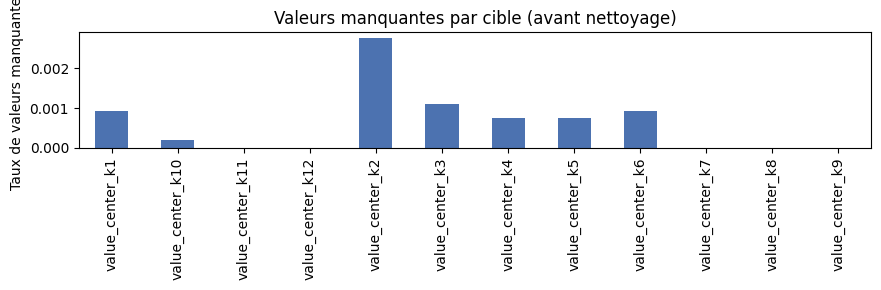

In [ ]:
missing_X = train[X_COLS].isna().mean().sort_values(ascending=False)
missing_Y = train[Y_COLS].isna().mean().sort_values(ascending=False)

print("Taux de valeurs manquantes - variables X (top 10) :")
print((missing_X.head(10) * 100).round(2).astype(str) + " %")
print("\nTaux de valeurs manquantes - cibles Y :")
print((missing_Y * 100).round(2).astype(str) + " %")

fig, ax = plt.subplots(figsize=(9, 3))
missing_Y.sort_index().plot(kind="bar", ax=ax, color="#4C72B0")
ax.set_ylabel("Taux de valeurs manquantes")
ax.set_title("Valeurs manquantes par cible (avant nettoyage)")
plt.tight_layout()
plt.show()


### 2.2 Valeurs aberrantes (outliers capteur)

L'objectif metier est de s'approcher de 0 : une distorsion optique realiste reste dans une plage bornee autour de 0. Une valeur tres eloignee de cette plage correspond generalement a une erreur de mesure du capteur (glitch), pas a un vrai defaut physique — on l'exclut donc de l'apprentissage (mise a `NaN`) plutot que de la laisser polluer le modele.

Le seuil ci-dessous est un point de depart a **confirmer visuellement** sur les histogrammes (a ajuster si besoin selon ce que montrent vos vraies donnees).


Statistiques descriptives des cibles Y (avant nettoyage) :
                    mean    std    min     max
value_center_k1   12.356  1.805  5.761   18.69
value_center_k2   10.219  1.820  4.352   17.62
value_center_k3   10.578  3.020  4.753  143.20
value_center_k4   10.271  2.364  5.014   24.51
value_center_k5   11.913  2.795  6.959  147.90
value_center_k6   12.345  2.309  5.144   19.19
value_center_k7   12.452  3.251  6.156  141.30
value_center_k8   13.443  2.465  5.488   22.16
value_center_k9   10.479  2.477  5.872  146.70
value_center_k10  10.179  2.199  4.792   17.86
value_center_k11  11.927  2.439  6.727   18.96
value_center_k12  12.609  2.721  4.982   20.33


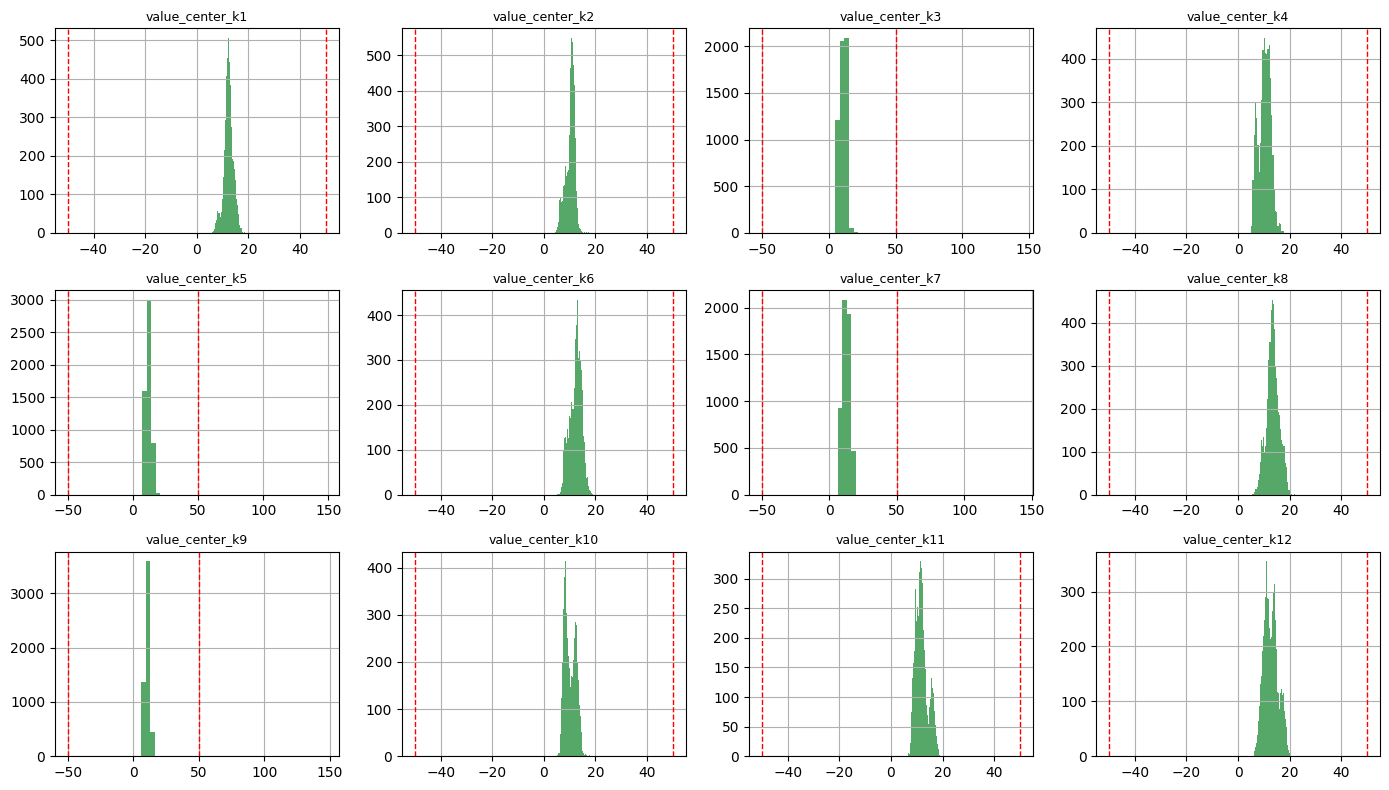


Valeurs |Y| > 50 detectees comme aberrantes (par cible) :
value_center_k3    1
value_center_k5    1
value_center_k7    1
value_center_k9    1
dtype: int64


In [ ]:
print("Statistiques descriptives des cibles Y (avant nettoyage) :")
print(train[Y_COLS].describe().T[["mean", "std", "min", "max"]].round(3))

OUTLIER_Y_MAX = 50  # seuil metier (valeur absolue) — a confirmer/ajuster selon les histogrammes

fig, axes = plt.subplots(3, 4, figsize=(14, 8))
for ax, col in zip(axes.ravel(), Y_COLS):
    train[col].hist(bins=40, ax=ax, color="#55A868")
    ax.axvline(OUTLIER_Y_MAX, color="red", linestyle="--", linewidth=1)
    ax.axvline(-OUTLIER_Y_MAX, color="red", linestyle="--", linewidth=1)
    ax.set_title(col, fontsize=9)
plt.tight_layout()
plt.show()

n_outliers = (train[Y_COLS].abs() > OUTLIER_Y_MAX).sum()
print(f"\nValeurs |Y| > {OUTLIER_Y_MAX} detectees comme aberrantes (par cible) :")
print(n_outliers[n_outliers > 0] if n_outliers.sum() > 0 else "Aucune valeur aberrante detectee au seuil actuel.")

train[Y_COLS] = train[Y_COLS].mask(train[Y_COLS].abs() > OUTLIER_Y_MAX)


## 3. Strategie de validation : split train (80%) / validation (20%)

Le split est effectue une seule fois sur l'ensemble labellise. L'imputation (mediane) et la standardisation (`StandardScaler`) sont ensuite ajustees **uniquement sur le train** pour eviter toute fuite d'information vers la validation.


In [ ]:
train_part, val_part = train_test_split(train, test_size=0.20, random_state=RANDOM_STATE)
print(f"Entrainement : {train_part.shape[0]} lignes ({train_part.shape[0] / len(train):.0%})")
print(f"Validation   : {val_part.shape[0]} lignes ({val_part.shape[0] / len(train):.0%})")

# Imputation des valeurs manquantes (mediane), ajustee sur le train uniquement
imputer = SimpleImputer(strategy="median").fit(train_part[X_COLS])
Xtr = pd.DataFrame(imputer.transform(train_part[X_COLS]), columns=X_COLS, index=train_part.index)
Xval = pd.DataFrame(imputer.transform(val_part[X_COLS]), columns=X_COLS, index=val_part.index)

# Standardisation, ajustee sur le train uniquement
scaler = StandardScaler().fit(Xtr)
Xtr_s = pd.DataFrame(scaler.transform(Xtr), columns=X_COLS, index=Xtr.index)
Xval_s = pd.DataFrame(scaler.transform(Xval), columns=X_COLS, index=Xval.index)


Entrainement : 4331 lignes (80%)
Validation   : 1083 lignes (20%)


## 4. Comparaison de modeles (parametres par defaut)

Chaque cible (`k1`...`k12`) a son propre pattern de valeurs manquantes : on entraine donc, pour chaque algorithme, **un modele independant par cible** (12 modeles), chacun uniquement sur les lignes ou cette cible est renseignee. Tous les algorithmes sont compares sur le **meme split** train/validation pour une comparaison equitable.

On mesure pour chacun : **R2** (metrique principale de selection), **MAE** et **RMSE** (metriques complementaires), et le temps d'entrainement.


In [ ]:
def make_rf(**kwargs):
    params = dict(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    params.update(kwargs)
    return RandomForestRegressor(**params)


def make_et(**kwargs):
    params = dict(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)
    params.update(kwargs)
    return ExtraTreesRegressor(**params)


def make_gb(**kwargs):
    params = dict(n_estimators=300, random_state=RANDOM_STATE)
    params.update(kwargs)
    return GradientBoostingRegressor(**params)


def make_hgb(**kwargs):
    params = dict(random_state=RANDOM_STATE)
    params.update(kwargs)
    return HistGradientBoostingRegressor(**params)


def make_xgb(**kwargs):
    if not HAS_XGBOOST:
        return None
    params = dict(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbosity=0)
    params.update(kwargs)
    return XGBRegressor(**params)


def make_lgbm(**kwargs):
    if not HAS_LIGHTGBM:
        return None
    params = dict(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1, verbose=-1)
    params.update(kwargs)
    return LGBMRegressor(**params)


def evaluate(model_factory, **kwargs):
    """Entraine un modele independant par cible (k1..k12) et retourne
    R2 / MAE / RMSE par cible (validation) + temps d'entrainement total.
    Retourne (None, None, None, None) si la bibliotheque n'est pas disponible."""
    r2s, maes, rmses = [], [], []
    t0 = time.time()
    for col in Y_COLS:
        m_tr = train_part[col].notna().values
        m_val = val_part[col].notna().values
        model = model_factory(**kwargs)
        if model is None:
            return None, None, None, None
        model.fit(Xtr_s[m_tr], train_part.loc[m_tr, col])
        pred = model.predict(Xval_s[m_val])
        y_true = val_part.loc[m_val, col]
        r2s.append(r2_score(y_true, pred))
        maes.append(mean_absolute_error(y_true, pred))
        rmses.append(np.sqrt(mean_squared_error(y_true, pred)))
    elapsed = time.time() - t0
    return np.array(r2s), np.array(maes), np.array(rmses), elapsed


# Tableau comparatif : une ligne par modele, alimente au fil des sections suivantes.
results_all = {}
per_target_r2 = {}


def register(name, r2s, maes, rmses, elapsed):
    if r2s is None:
        print(f"{name:32s} : non disponible (bibliotheque non installee) — ignore")
        return
    results_all[name] = {
        "R2_moyen": r2s.mean(), "MAE_moyen": maes.mean(), "RMSE_moyen": rmses.mean(),
        "temps_entrainement_s": elapsed,
    }
    per_target_r2[name] = r2s
    print(f"{name:32s} : R2 moyen={r2s.mean():.4f}  MAE moyen={maes.mean():.4f}  "
          f"RMSE moyen={rmses.mean():.4f}  ({elapsed:.1f}s)")


In [ ]:
BASELINE_FACTORIES = {
    "Random Forest (baseline)": make_rf,
    "Extra Trees": make_et,
    "Gradient Boosting": make_gb,
    "HistGradientBoosting": make_hgb,
    "XGBoost": make_xgb,
    "LightGBM": make_lgbm,
}

print("=== Evaluation de chaque famille de modele (parametres par defaut) ===\n")
for name, factory in BASELINE_FACTORIES.items():
    register(name, *evaluate(factory))

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(len(Y_COLS))
for name, r2s in per_target_r2.items():
    ax.plot(x, r2s, marker="o", label=name)
ax.set_xticks(x)
ax.set_xticklabels(Y_COLS, rotation=45, ha="right")
ax.set_ylabel("R2 (validation)")
ax.set_title("R2 par cible — comparaison des modeles (parametres par defaut)")
ax.axhline(0, color="black", linewidth=0.8)
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()


## 5. Optimisation et regularisation de Random Forest (multi-output, validation croisee 5-fold)

Le benchmark de la section 4 a montre un ecart important entre R2 d'entrainement (1.0, parfait) et R2 de validation pour Random Forest a parametres par defaut : les arbres n'ont **aucune limite de profondeur** et peuvent isoler une seule ligne par feuille (`min_samples_leaf=1`), donc ils memorisent l'entrainement plutot que d'apprendre une tendance generale (sur-apprentissage).

Cette section cherche des hyperparametres qui **regularisent** le modele — directement sur l'architecture **multi-output** qui sera deployee (pas sur l'approche independante de la section 4) :
- `max_depth` **plus petit** (arbres moins profonds, moins de memorisation) ;
- `min_samples_leaf` et `min_samples_split` **plus grands** (chaque feuille/coupure doit s'appuyer sur plusieurs exemples, pas un seul) ;
- `max_features` limite (chaque coupure ne voit qu'une partie des variables, decorrelation entre arbres) ;
- `n_estimators` **suffisant** (300 a 500 : plus d'arbres reduit la variance sans jamais aggraver le sur-apprentissage, contrairement aux 4 parametres precedents).

Pour choisir honnetement entre les combinaisons, chacune est evaluee par **validation croisee 5-fold** (et non un split unique) : a chaque combinaison correspondent 5 valeurs de R2 train et 5 de R2 validation, dont on retient la moyenne — cela evite de choisir une combinaison qui colle par hasard a un seul decoupage train/validation.


In [ ]:
# Le modele final est multi-output : on regularise directement cette
# architecture (pas l'approche independante de la section 4), par
# validation croisee 5-fold sur toutes les lignes ou les 12 cibles sont
# renseignees.
mask_complete_search = train[Y_COLS].notna().all(axis=1).values
train_complete_search = train[mask_complete_search].reset_index(drop=True)
print(f"Lignes utilisees pour la recherche d'hyperparametres : {len(train_complete_search)} / {len(train)} "
      f"(lignes avec les 12 cibles renseignees)")

N_SPLITS_SEARCH = 5
kf_search = KFold(n_splits=N_SPLITS_SEARCH, shuffle=True, random_state=RANDOM_STATE)


def evaluate_multioutput_cv(params, data, kf):
    """Entraine un RandomForestRegressor multi-output sur chaque fold et
    retourne (R2_train par fold, R2_val par fold), chacun moyenne sur les
    12 cibles. Permet de comparer clairement train vs validation, et pas
    seulement de retenir un score unique."""
    r2_train_folds, r2_val_folds = [], []
    for tr_idx, va_idx in kf.split(data):
        tr_df, va_df = data.iloc[tr_idx], data.iloc[va_idx]

        imp = SimpleImputer(strategy="median").fit(tr_df[X_COLS])
        Xtr = pd.DataFrame(imp.transform(tr_df[X_COLS]), columns=X_COLS)
        Xva = pd.DataFrame(imp.transform(va_df[X_COLS]), columns=X_COLS)
        sc = StandardScaler().fit(Xtr)
        Xtr_s = pd.DataFrame(sc.transform(Xtr), columns=X_COLS)
        Xva_s = pd.DataFrame(sc.transform(Xva), columns=X_COLS)

        model = RandomForestRegressor(**params, random_state=RANDOM_STATE, n_jobs=-1)
        model.fit(Xtr_s, tr_df[Y_COLS].reset_index(drop=True))
        pred_tr = model.predict(Xtr_s)
        pred_va = model.predict(Xva_s)

        y_tr = tr_df[Y_COLS].reset_index(drop=True)
        y_va = va_df[Y_COLS].reset_index(drop=True)
        r2_train_folds.append(np.mean([r2_score(y_tr.iloc[:, j], pred_tr[:, j]) for j in range(len(Y_COLS))]))
        r2_val_folds.append(np.mean([r2_score(y_va.iloc[:, j], pred_va[:, j]) for j in range(len(Y_COLS))]))
    return np.array(r2_train_folds), np.array(r2_val_folds)


# --- Reference : configuration non regularisee (parametres par defaut) ---
# sert de point de comparaison "avant / apres" regularisation.
BASELINE_PARAMS_REF = dict(n_estimators=300, max_depth=None, min_samples_leaf=1, min_samples_split=2, max_features=1.0)
r2_tr_ref, r2_va_ref = evaluate_multioutput_cv(BASELINE_PARAMS_REF, train_complete_search, kf_search)

# --- Grille de regularisation : max_depth plus petit, min_samples_leaf et
# min_samples_split plus grands, max_features limite, n_estimators suffisant.
PARAM_GRID_RF_REG = dict(
    n_estimators=[300, 500],
    max_depth=[4, 6, 8, 10, 14],
    min_samples_leaf=[2, 4, 8, 16, 32],
    min_samples_split=[2, 5, 10, 20],
    max_features=["sqrt", "log2", 0.5, 0.7],
)

N_ITER = 15  # nombre de combinaisons testees ; augmenter si le temps de calcul le permet
candidates = list(ParameterSampler(PARAM_GRID_RF_REG, n_iter=N_ITER, random_state=RANDOM_STATE))

search_log = [{
    **BASELINE_PARAMS_REF,
    "R2_train_moyen": r2_tr_ref.mean(), "R2_train_std": r2_tr_ref.std(),
    "R2_val_moyen": r2_va_ref.mean(), "R2_val_std": r2_va_ref.std(),
    "ecart_train_val": r2_tr_ref.mean() - r2_va_ref.mean(),
    "config": "reference (non regularise)",
}]

best_score = r2_va_ref.mean()
best_params_rf = BASELINE_PARAMS_REF
best_r2_train, best_r2_val = r2_tr_ref.mean(), r2_va_ref.mean()

for params in candidates:
    r2_tr, r2_va = evaluate_multioutput_cv(params, train_complete_search, kf_search)
    search_log.append({
        **params,
        "R2_train_moyen": r2_tr.mean(), "R2_train_std": r2_tr.std(),
        "R2_val_moyen": r2_va.mean(), "R2_val_std": r2_va.std(),
        "ecart_train_val": r2_tr.mean() - r2_va.mean(),
        "config": "candidat regularise",
    })
    if r2_va.mean() > best_score:
        best_score = r2_va.mean()
        best_params_rf = params
        best_r2_train, best_r2_val = r2_tr.mean(), r2_va.mean()

search_log_df = pd.DataFrame(search_log).sort_values("R2_val_moyen", ascending=False)
cols_order = ["config", "n_estimators", "max_depth", "min_samples_leaf", "min_samples_split",
              "max_features", "R2_train_moyen", "R2_val_moyen", "ecart_train_val", "R2_val_std"]
print("=== Comparaison train vs validation, 5-fold, toutes les combinaisons testees ===")
print(search_log_df[cols_order].round(4).to_string(index=False))

ecart_ref = r2_tr_ref.mean() - r2_va_ref.mean()
ecart_best = best_r2_train - best_r2_val
print(f"\nReference (non regularise)  : R2_train={r2_tr_ref.mean():.4f}  R2_val={r2_va_ref.mean():.4f}  ecart={ecart_ref:.4f}")
print(f"Meilleure config retenue    : R2_train={best_r2_train:.4f}  R2_val={best_r2_val:.4f}  ecart={ecart_best:.4f}")
print(f"Hyperparametres retenus     : {best_params_rf}")
if best_params_rf is BASELINE_PARAMS_REF:
    print("\nAucun candidat regularise n'a fait mieux (R2 de validation) que la configuration par "
          "defaut sur ce jeu de donnees : on garde la reference. Le sur-apprentissage (ecart eleve) "
          "n'est donc pas au prix du R2 de validation, mais reste a signaler dans le rapport comme "
          "une limite (modele moins robuste a des donnees hors distribution).")
elif ecart_best < ecart_ref:
    print(f"\n-> Ecart train/val reduit de {ecart_ref:.3f} a {ecart_best:.3f} : moins de sur-apprentissage, "
          "pour un R2 de validation egal ou meilleur. Configuration retenue pour le modele final.")
else:
    print(f"\n-> Le meilleur R2 de validation ({best_r2_val:.4f}) n'a pas reduit l'ecart train/val "
          f"(reste a {ecart_best:.4f}) : a mentionner comme limite dans le rapport.")


## 6. Modeles independants (1 par cible) vs un seul modele multi-output

Jusqu'ici, chaque cible `k1...k12` a son propre modele, entraine uniquement sur les lignes ou elle est renseignee (ce qui exploite un maximum de donnees malgre les valeurs manquantes propres a chaque cible). L'alternative est un **seul modele multi-output** : `RandomForestRegressor` sait nativement predire plusieurs cibles a la fois (pas besoin de `MultiOutputRegressor`, qui se contenterait d'entrainer 12 modeles independants en coulisses) — chaque arbre choisit ses coupures pour reduire la variance sur les 12 cibles **conjointement**, ce qui peut capter les correlations entre points. Contrepartie : il ne peut s'entrainer que sur les lignes ou **les 12 cibles sont simultanement renseignees**, donc potentiellement moins de donnees.

**C'est ce modele multi-output qui est retenu comme modele final du projet** (section 7), pour avoir un seul objet a deployer plutot que 12 — voir la discussion sur le choix en section 7.


In [ ]:
mask_complete_tr = train_part[Y_COLS].notna().all(axis=1).values
mask_complete_val = val_part[Y_COLS].notna().all(axis=1).values

print(f"Lignes disponibles - approche independante : jusqu'a {len(train_part)} par cible (selon le taux de NaN de chaque cible)")
print(f"Lignes disponibles - approche multi-output  : {mask_complete_tr.sum()} "
      f"(lignes ou les 12 cibles sont renseignees)")

t0 = time.time()
multi_model = RandomForestRegressor(**best_params_rf, random_state=RANDOM_STATE, n_jobs=-1)
multi_model.fit(Xtr_s[mask_complete_tr], train_part.loc[mask_complete_tr, Y_COLS])
elapsed_multi = time.time() - t0

pred_multi = multi_model.predict(Xval_s[mask_complete_val])
y_true_multi = val_part.loc[mask_complete_val, Y_COLS]

r2_multi = np.array([r2_score(y_true_multi.iloc[:, i], pred_multi[:, i]) for i in range(len(Y_COLS))])
mae_multi = np.array([mean_absolute_error(y_true_multi.iloc[:, i], pred_multi[:, i]) for i in range(len(Y_COLS))])
rmse_multi = np.array([np.sqrt(mean_squared_error(y_true_multi.iloc[:, i], pred_multi[:, i])) for i in range(len(Y_COLS))])

register("Random Forest (multi-output)", r2_multi, mae_multi, rmse_multi, elapsed_multi)

print(f"\nR2 moyen  - independant (RF baseline) : {results_all['Random Forest (baseline)']['R2_moyen']:.4f}"
      f"  |  multi-output (RF) : {r2_multi.mean():.4f}")


## 7. Tableau comparatif complet et choix du modele final

Toutes les experiences precedentes sont reunies dans un seul tableau : **R2 moyen et par cible, MAE moyen et par cible, RMSE moyen et par cible, temps d'entrainement**. C'est ce tableau qui sert de preuve dans le rapport de stage (« comment je suis passe du modele initial au modele final, et pourquoi »).

⚠️ **Choix impose, different du meilleur R2 du tableau :** le modele exporte est le **Random Forest multi-output**, pas forcement celui qui a le R2 le plus eleve dans le tableau ci-dessous (celui-ci ne compare que des modeles *independants*, 1 par cible). Le projet a besoin d'un seul modele qui predit les 12 cibles en une fois (plus simple a deployer, capture des correlations entre points) : c'est un choix de conception, pas uniquement une decision basee sur le R2. Le tableau reste neanmoins la preuve qu'un benchmark serieux (7 approches) a ete mene avant de faire ce choix.


In [ ]:
comparison_rows = {}
for name, r2s in per_target_r2.items():
    row = dict(results_all[name])
    for col, v in zip(Y_COLS, r2s):
        row[f"R2_{col}"] = v
    comparison_rows[name] = row

comparison_df = pd.DataFrame(comparison_rows).T
comparison_summary = comparison_df[["R2_moyen", "MAE_moyen", "RMSE_moyen", "temps_entrainement_s"]]
comparison_summary = comparison_summary.sort_values("R2_moyen", ascending=False)

print("=== Tableau comparatif (a titre informatif, trie par R2 decroissant) ===")
print(comparison_summary.round(4))

comparison_df.to_csv(f"{ARTIFACTS_DIR}/model_comparison_full.csv")
comparison_summary.to_csv(f"{ARTIFACTS_DIR}/model_comparison_summary.csv")

# Choix FIGE du projet : Random Forest multi-output (un seul modele pour les
# 12 cibles), meme s'il n'est pas premier du tableau ci-dessus. On reutilise
# les hyperparametres optimises pour Random Forest (section 5) : ce sont des
# reglages d'arbre (nombre d'arbres, profondeur...) valables que le modele
# predise 1 ou 12 cibles a la fois.
WINNER = "Random Forest (multi-output)"
best_params = dict(best_params_rf)

meilleur_independant = comparison_summary.index[0]
print(f"\n>>> Meilleur modele independant du tableau : {meilleur_independant} "
      f"(R2 moyen={comparison_summary.loc[meilleur_independant, 'R2_moyen']:.4f})")
print(f">>> Modele retenu pour le projet (impose)   : {WINNER} "
      f"(R2 moyen={comparison_summary.loc[WINNER, 'R2_moyen']:.4f})")
print("NOTE : le choix du multi-output n'est pas purement base sur le R2 — c'est "
      "un choix de conception (un seul modele a deployer, correlations entre "
      "les 12 points prises en compte). Le tableau ci-dessus documente le "
      "benchmark effectue avant de faire ce choix.")


## 8. Evaluation detaillee du modele final (validation)

In [ ]:
r2_final, mae_final, rmse_final = r2_multi, mae_multi, rmse_multi
results = pd.DataFrame({"cible": Y_COLS, "R2": r2_final, "MAE": mae_final, "RMSE": rmse_final}).set_index("cible")
results.loc["GLOBAL (moyenne)"] = [r2_final.mean(), mae_final.mean(), rmse_final.mean()]
print(results.round(4))

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
results.iloc[:-1]["R2"].plot(kind="bar", ax=axes[0], color="#55A868")
axes[0].axhline(0, color="black", linewidth=0.8)
axes[0].set_title("R2 par point (k1-k12)")
axes[0].set_ylabel("R2")

results.iloc[:-1]["MAE"].plot(kind="bar", ax=axes[1], color="#C44E52")
axes[1].set_title("MAE par point (k1-k12)")
axes[1].set_ylabel("MAE")

results.iloc[:-1]["RMSE"].plot(kind="bar", ax=axes[2], color="#8172B2")
axes[2].set_title("RMSE par point (k1-k12)")
axes[2].set_ylabel("RMSE")

plt.tight_layout()
plt.show()


## 9. Modele final & export des predictions (jeu de test aveugle)

Le modele final est reentraine avec les hyperparametres optimises, sur **l'ensemble des donnees labellisees** (train + validation) afin de maximiser l'information disponible avant de predire le jeu de test aveugle. L'ordre des lignes du fichier `infer` est preserve.


In [ ]:
# Imputer + scaler finaux, reajustes sur l'ensemble des donnees labellisees.
# Le modele multi-output ne peut s'entrainer que sur les lignes ou les 12
# cibles sont renseignees (contrairement a l'approche independante).
mask_complete_all = train[Y_COLS].notna().all(axis=1).values
print(f"Lignes utilisees pour l'entrainement final : {mask_complete_all.sum()} / {len(train)} "
      f"(lignes avec les 12 cibles renseignees)")

imputer_final = SimpleImputer(strategy="median").fit(train[X_COLS])
Xall = pd.DataFrame(imputer_final.transform(train[X_COLS]), columns=X_COLS, index=train.index)
scaler_final = StandardScaler().fit(Xall)
Xall_s = pd.DataFrame(scaler_final.transform(Xall), columns=X_COLS, index=train.index)

Xinf = pd.DataFrame(imputer_final.transform(infer[X_COLS]), columns=X_COLS, index=infer.index)
Xinf_s = pd.DataFrame(scaler_final.transform(Xinf), columns=X_COLS, index=infer.index)

final_model = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
final_model.fit(Xall_s[mask_complete_all], train.loc[mask_complete_all, Y_COLS])

# Un seul appel predict() renvoie directement les 12 colonnes (plus besoin de
# boucler sur Y_COLS comme avec l'approche independante).
pred_df = pd.DataFrame(final_model.predict(Xinf_s), columns=Y_COLS, index=infer.index).reset_index(drop=True)
assert len(pred_df) == len(infer), "Le nombre de lignes doit correspondre au jeu de test aveugle."
assert pred_df.isna().sum().sum() == 0, "Aucune prediction ne doit etre manquante."

OUTPUT_CSV = "predictions_Y_v3.csv"
pred_df.to_csv(OUTPUT_CSV, index=False)
print(f"Fichier ecrit : {OUTPUT_CSV}  {pred_df.shape}")
pred_df.head()


Fichier ecrit : predictions_Y_v3.csv  (4413, 12)


,value_center_k1,value_center_k2,value_center_k3,value_center_k4,value_center_k5,value_center_k6,value_center_k7,value_center_k8,value_center_k9,value_center_k10,value_center_k11,value_center_k12
0,8.778609,6.111909,8.698998,9.002948,11.082712,10.247206,8.724852,9.264673,8.933605,8.115350,10.199579,9.092333
1,8.901689,6.589256,7.765875,9.479186,11.558206,9.226980,8.530672,10.003868,8.655228,8.987519,9.507047,9.711886
2,8.447736,6.716481,7.698556,9.976515,12.083042,10.112254,8.200507,11.079824,8.649489,9.209849,8.994587,10.014200
3,8.316705,6.642074,7.902602,10.108515,11.709045,9.929704,8.118969,11.045117,8.853503,9.407631,9.043004,10.055430
4,9.620468,6.494119,8.053647,9.002004,10.402678,9.615626,8.665624,9.702872,7.995894,10.521969,9.796614,9.704426


## 10. Sauvegarde des artefacts (pour l'interface Streamlit)

Ces fichiers sont lus par `app.py` pour presenter le projet sans avoir a relancer l'entrainement. `models.joblib` et `best_pipeline.joblib` contiennent maintenant **un seul modele** (multi-output) plutot qu'un dict de 12 modeles.


In [ ]:
# compress=3 : reduit fortement la taille des fichiers (utile pour les forets
# d'arbres, volumineuses par defaut) et evite les echecs de telechargement
# Colab sur les gros fichiers.
joblib.dump(imputer_final, f"{ARTIFACTS_DIR}/imputer.joblib", compress=3)
joblib.dump(scaler_final, f"{ARTIFACTS_DIR}/scaler.joblib", compress=3)
joblib.dump(final_model, f"{ARTIFACTS_DIR}/models.joblib", compress=3)


def _to_jsonable(v):
    if isinstance(v, (np.integer,)):
        return int(v)
    if isinstance(v, (np.floating,)):
        return float(v)
    return v


metadata = {
    "winner_algo": WINNER,
    "model_architecture": "multi_output",  # un seul modele predit les 12 cibles a la fois
    "best_params": {k: _to_jsonable(v) for k, v in best_params.items()},
    "x_cols": X_COLS,
    "y_cols": Y_COLS,
    "outlier_y_max": OUTLIER_Y_MAX,
    "n_train_labelled": int(len(train)),
    "n_infer": int(len(infer)),
    "model_comparison": comparison_summary.reset_index().rename(columns={"index": "modele"}).to_dict(orient="records"),
    "results_per_target": results.reset_index().to_dict(orient="records"),
}
with open(f"{ARTIFACTS_DIR}/metadata.json", "w", encoding="utf-8") as f:
    json.dump(metadata, f, indent=2, ensure_ascii=False)

pred_df.to_csv(f"{ARTIFACTS_DIR}/predictions.csv", index=False)
infer[X_COLS].reset_index(drop=True).to_csv(f"{ARTIFACTS_DIR}/infer_X.csv", index=False)

# Bundle unique pratique a charger depuis l'application (un seul joblib.load
# suffit pour recuperer tout ce qu'il faut pour predire sur de nouvelles pieces) :
best_pipeline_bundle = {
    "imputer": imputer_final,
    "scaler": scaler_final,
    "model": final_model,            # un seul modele multi-output (pas un dict)
    "x_cols": X_COLS,
    "y_cols": Y_COLS,
    "winner_algo": WINNER,
    "model_architecture": "multi_output",
    "best_params": {k: _to_jsonable(v) for k, v in best_params.items()},
}
joblib.dump(best_pipeline_bundle, f"{ARTIFACTS_DIR}/best_pipeline.joblib", compress=3)

print("Artefacts sauvegardes dans le dossier :", ARTIFACTS_DIR)
print(os.listdir(ARTIFACTS_DIR))


## 11. Telechargement des resultats (Google Colab)

Regroupe tout ce qu'il faut pour l'interface Streamlit (`artifacts/`) et le
CSV de predictions dans une seule archive, puis declenche son
telechargement vers votre ordinateur.

**Etapes suivantes une fois le zip telecharge :**
1. Extrayez `resultats_projet.zip`
2. Placez le dossier `artifacts/` a cote de `app.py` (l'interface Streamlit
   fournie precedemment)
3. En local : `pip install -r requirements.txt` puis `streamlit run app.py`


In [ ]:
import shutil
from pathlib import Path

BUNDLE_DIR = Path("bundle_resultats")
if BUNDLE_DIR.exists():
    shutil.rmtree(BUNDLE_DIR)
BUNDLE_DIR.mkdir()

shutil.copytree(ARTIFACTS_DIR, BUNDLE_DIR / "artifacts")
shutil.copy(OUTPUT_CSV, BUNDLE_DIR / OUTPUT_CSV)

zip_path = shutil.make_archive("resultats_projet", "zip", root_dir=BUNDLE_DIR)
zip_size_mb = os.path.getsize(zip_path) / (1024 * 1024)
print(f"Archive prete : {zip_path}  ({zip_size_mb:.1f} Mo)")
print(f"Contenu : artifacts/ (pour Streamlit) + {OUTPUT_CSV} (livrable a l'encadrant)")

if IN_COLAB:
    if zip_size_mb > 80:
        print(f"\n⚠️ Archive volumineuse ({zip_size_mb:.0f} Mo) : le telechargement automatique "
              "peut echouer ou rester bloque sur la barre de progression.")
        print("Si ca bloque plus de 1-2 minutes, deux alternatives fiables :")
        print("  1) Panneau de fichiers (icone dossier a gauche) -> clic droit sur "
              f"'{zip_path}' -> Telecharger.")
        print("  2) Copier vers Google Drive :")
        print("       from google.colab import drive; drive.mount('/content/drive')")
        print(f"       import shutil; shutil.copy('{zip_path}', '/content/drive/MyDrive/resultats_projet.zip')")
    try:
        colab_files.download(zip_path)
    except Exception as e:
        print(f"\nLe telechargement automatique a echoue ({e}). "
              "Utilisez une des deux alternatives ci-dessus.")
else:
    print(f"Environnement local : recuperez directement '{zip_path}' dans le dossier de travail.")

Archive prete : /content/resultats_projet.zip
Contenu : artifacts/ (pour Streamlit) + predictions_Y_v3.csv (livrable a l'encadrant)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>


# 12. Test du modele (validation croisee, matrice de confusion)

=== Validation croisee (5-Fold) — modele : Random Forest ===

                 R2_train          R2_val         MAE_val        
                     mean     std    mean     std    mean     std
cible                                                            
value_center_k1    0.7954  0.0064  0.6445  0.0136  0.8105  0.0148
value_center_k10   0.9168  0.0011  0.7886  0.0056  0.7573  0.0109
value_center_k11   0.9089  0.0026  0.7837  0.0142  0.8417  0.0213
value_center_k12   0.9060  0.0025  0.7766  0.0159  0.9212  0.0215
value_center_k2    0.8790  0.0033  0.7483  0.0130  0.6880  0.0177
value_center_k3    0.9159  0.0016  0.8101  0.0079  0.7692  0.0219
value_center_k4    0.8827  0.0011  0.7319  0.0134  0.9042  0.0278
value_center_k5    0.8765  0.0024  0.7319  0.0132  0.8067  0.0204
value_center_k6    0.8833  0.0033  0.7440  0.0090  0.8806  0.0184
value_center_k7    0.9008  0.0020  0.7590  0.0097  1.0027  0.0117
value_center_k8    0.8809  0.0022  0.7203  0.0230  0.9771  0.0188
value_center_k

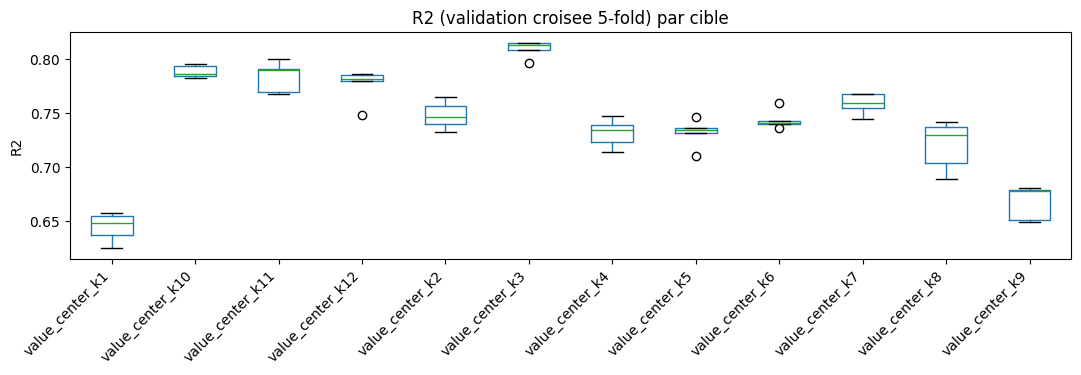

In [ ]:
from sklearn.model_selection import KFold

N_SPLITS = 5
kf = KFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)

# Le modele multi-output a besoin des 12 cibles renseignees simultanement.
mask_complete = train[Y_COLS].notna().all(axis=1).values
train_complete = train[mask_complete].reset_index(drop=True)
print(f"Lignes utilisees pour la validation croisee : {len(train_complete)} / {len(train)} "
      f"(lignes avec les 12 cibles renseignees)")

fold_records = []
# Predictions "out-of-fold" (OOF) : chaque ligne est predite par un modele
# qui ne l'a jamais vue a l'entrainement -> utilisees ensuite pour la
# matrice de confusion et le test du Chi-2 (evaluation hors echantillon,
# pas sur les donnees d'entrainement).
oof_pred = pd.DataFrame(index=train_complete.index, columns=Y_COLS, dtype=float)

for fold_i, (tr_idx, va_idx) in enumerate(kf.split(train_complete), start=1):
    tr_df, va_df = train_complete.iloc[tr_idx], train_complete.iloc[va_idx]

    imp_f = SimpleImputer(strategy="median").fit(tr_df[X_COLS])
    Xtr_f = pd.DataFrame(imp_f.transform(tr_df[X_COLS]), columns=X_COLS, index=tr_df.index)
    Xva_f = pd.DataFrame(imp_f.transform(va_df[X_COLS]), columns=X_COLS, index=va_df.index)

    sc_f = StandardScaler().fit(Xtr_f)
    Xtr_fs = pd.DataFrame(sc_f.transform(Xtr_f), columns=X_COLS, index=Xtr_f.index)
    Xva_fs = pd.DataFrame(sc_f.transform(Xva_f), columns=X_COLS, index=Xva_f.index)

    model = RandomForestRegressor(**best_params, random_state=RANDOM_STATE, n_jobs=-1)
    model.fit(Xtr_fs, tr_df[Y_COLS])
    pred_val = model.predict(Xva_fs)
    pred_train = model.predict(Xtr_fs)

    oof_pred.loc[va_df.index, Y_COLS] = pred_val

    for j, col in enumerate(Y_COLS):
        fold_records.append({
            "fold": fold_i, "cible": col,
            "R2_train": r2_score(tr_df[col], pred_train[:, j]),
            "R2_val": r2_score(va_df[col], pred_val[:, j]),
            "MAE_val": mean_absolute_error(va_df[col], pred_val[:, j]),
        })

fold_df = pd.DataFrame(fold_records)
print(f"=== Validation croisee ({N_SPLITS}-Fold) — modele : {WINNER} ===\n")
print(fold_df.groupby("cible")[["R2_train", "R2_val", "MAE_val"]].agg(["mean", "std"]).round(4))

gap = (fold_df.groupby("cible")["R2_train"].mean() - fold_df.groupby("cible")["R2_val"].mean()).mean()
print(f"\nR2 global (validation croisee)     : {fold_df['R2_val'].mean():.4f}")
print(f"MAE global (validation croisee)    : {fold_df['MAE_val'].mean():.4f}")
print(f"Ecart moyen R2 train - R2 val       : {gap:.4f}  "
      f"({'sur-apprentissage probable' if gap > 0.20 else 'pas de sur-apprentissage marque'})")

fig, ax = plt.subplots(figsize=(11, 4))
fold_df.boxplot(column="R2_val", by="cible", ax=ax, grid=False)
ax.set_title(f"R2 (validation croisee {N_SPLITS}-fold) par cible — {WINNER}")
ax.set_xlabel("")
ax.set_ylabel("R2")
plt.xticks(rotation=45, ha="right")
plt.suptitle("")
plt.tight_layout()
plt.show()


Distribution de |distorsion optique| (toutes cibles, apres nettoyage outliers) :
count    64924.000
mean        11.556
std          2.528
min          4.352
25%          9.739
50%         11.560
75%         13.180
max         24.510
dtype: float64

Percentiles : {0.1: 8.219, 0.25: 9.739, 0.5: 11.56, 0.75: 13.18, 0.9: 14.85}

TOLERANCE utilisee : 11.560  <-- a remplacer par la vraie tolerance metier si connue


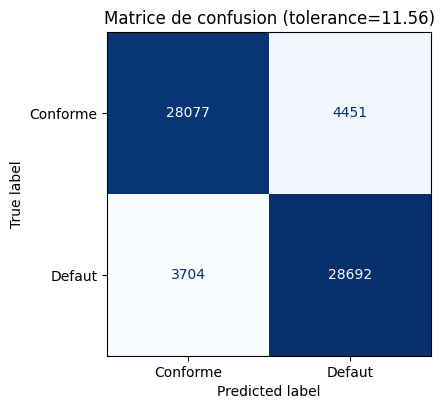


=== Test du Chi-2 ===
chi2 = 36418.68   dof = 1   p-value = 0
effectif minimum attendu = 15858.2 (doit etre >= 5 pour fiabilite)
-> Association significative (le modele bat le hasard).

=== Metriques (pos_label = 'Defaut', la classe qui compte le plus en QC) ===
R2 (validation croisee)  : 0.7422
Accuracy                 : 0.8744
F1-score                 : 0.8756
Recall (rappel)          : 0.8857
Precision                : 0.8657

=== Rapport de classification complet ===
              precision    recall  f1-score   support

    Conforme       0.88      0.86      0.87     32528
      Defaut       0.87      0.89      0.88     32396

    accuracy                           0.87     64924
   macro avg       0.87      0.87      0.87     64924
weighted avg       0.87      0.87      0.87     64924



In [ ]:
from sklearn.metrics import (
    ConfusionMatrixDisplay, accuracy_score, classification_report,
    confusion_matrix, f1_score, precision_score, recall_score,
)
from scipy.stats import chi2_contingency

# --- 1) Choix de la tolerance de conformite -------------------------------
# La distorsion est une valeur CONTINUE : pour calculer une matrice de
# confusion / accuracy / F1 / recall, il faut d'abord la transformer en
# decision binaire Conforme / Defaut via une tolerance metier.
abs_y = train_complete[Y_COLS].abs().stack()
print("Distribution de |distorsion optique| (toutes cibles, lignes completes) :")
print(abs_y.describe().round(3))
print("\nPercentiles :", abs_y.quantile([0.1, 0.25, 0.5, 0.75, 0.9]).round(3).to_dict())

# Valeur par defaut = mediane reelle des donnees (garantit un partage non
# degenere Conforme/Defaut). A REMPLACER par la vraie tolerance qualite du
# cahier des charges des que vous la connaissez.
TOLERANCE = float(abs_y.median())
print(f"\nTOLERANCE utilisee : {TOLERANCE:.3f}  <-- a remplacer par la vraie tolerance metier si connue")

# --- 2) Matrice de confusion (a partir des predictions out-of-fold) -------
all_true, all_pred = [], []
for col in Y_COLS:
    y_true_cls = (train_complete[col].abs() <= TOLERANCE).map({True: "Conforme", False: "Defaut"})
    y_pred_cls = (oof_pred[col].abs() <= TOLERANCE).map({True: "Conforme", False: "Defaut"})
    all_true += list(y_true_cls)
    all_pred += list(y_pred_cls)

cm = confusion_matrix(all_true, all_pred, labels=["Conforme", "Defaut"])

fig, ax = plt.subplots(figsize=(4.5, 4.5))
ConfusionMatrixDisplay(cm, display_labels=["Conforme", "Defaut"]).plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title(f"Matrice de confusion (tolerance={TOLERANCE:.2f})")
plt.tight_layout()
plt.show()

if cm.min() == 0 and (cm.sum(axis=0) == 0).any() or (cm.sum(axis=1) == 0).any():
    print("\n⚠️ Une des deux classes est absente (matrice degeneree) : ajustez TOLERANCE "
          "ci-dessus (voir les percentiles) avant d'interpreter les metriques.")

# --- 3) Test du Chi-2 : le modele fait-il mieux que le hasard ? ----------
try:
    chi2, p_value, dof, expected = chi2_contingency(cm)
    print(f"\n=== Test du Chi-2 ===")
    print(f"chi2 = {chi2:.2f}   dof = {dof}   p-value = {p_value:.3g}")
    print(f"effectif minimum attendu = {expected.min():.1f} (doit etre >= 5 pour fiabilite)")
    print("-> Association significative (le modele bat le hasard)." if p_value < 0.05
          else "-> Association NON significative.")
except ValueError:
    print("\nChi-2 non calculable : matrice de confusion degeneree (une seule classe presente). "
          "Ajustez TOLERANCE ci-dessus.")

# --- 4) R2, Accuracy, F1, Recall -------------------------------------------
r2_global = fold_df["R2_val"].mean()  # cf. cellule de validation croisee ci-dessus

print(f"\n=== Metriques (pos_label = 'Defaut', la classe qui compte le plus en QC) ===")
print(f"R2 (validation croisee)  : {r2_global:.4f}")
print(f"Accuracy                 : {accuracy_score(all_true, all_pred):.4f}")
print(f"F1-score                 : {f1_score(all_true, all_pred, pos_label='Defaut'):.4f}")
print(f"Recall (rappel)          : {recall_score(all_true, all_pred, pos_label='Defaut'):.4f}")
print(f"Precision                : {precision_score(all_true, all_pred, pos_label='Defaut'):.4f}")

print("\n=== Rapport de classification complet ===")
print(classification_report(all_true, all_pred, target_names=["Conforme", "Defaut"]))
